In [2]:
import os
import pypsa
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [3]:
path = Path.cwd().parent / 'resources'
regions = gpd.read_file(path / 'regions_onshore_base_s_50.geojson')

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


In [4]:
path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc')

INFO:pypsa.io:Imported network base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [5]:
n.buses.loc[n.buses.carrier == 'gas'].head()

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_lv,location,country,substation_off
Bus,,,,,,,,,,,,,,,,
AL0 0 gas,1.0,,19.845426,41.518089,gas,MWh_LHV,1.0,0.0,inf,PQ,,,NaN,AL0 0,AL,NaN
AT0 0 gas,1.0,,14.281561,47.640213,gas,MWh_LHV,1.0,0.0,inf,PQ,,,NaN,AT0 0,AT,NaN
BA0 0 gas,1.0,,18.047126,43.879730,gas,MWh_LHV,1.0,0.0,inf,PQ,,,NaN,BA0 0,BA,NaN
BE0 0 gas,1.0,,4.888784,50.729762,gas,MWh_LHV,1.0,0.0,inf,PQ,,,NaN,BE0 0,BE,NaN
BG0 0 gas,1.0,,24.656324,42.922999,gas,MWh_LHV,1.0,0.0,inf,PQ,,,NaN,BG0 0,BG,NaN


In [6]:
forwards = n.links.index[
    (n.links.carrier == 'gas pipeline') &
    (~n.links.index.str.contains('reversed')) &
    (n.links.index.str.contains('DE')) &
    (n.links.index.str.contains('FR'))
    ]
backwards = n.links.index[
    (n.links.carrier == 'gas pipeline') &
    (n.links.index.str.contains('reversed')) &
    (n.links.index.str.contains('DE')) &
    (n.links.index.str.contains('FR'))
    ]

In [7]:
num = 1
pairing = [forwards[num], backwards[num]]
print(pairing)

['gas pipeline FR0 4 -> DE0 4', 'gas pipeline FR0 4 -> DE0 4-reversed']


In [8]:
n.links.loc[pairing].T

Link,gas pipeline FR0 4 -> DE0 4,gas pipeline FR0 4 -> DE0 4-reversed
bus0,FR0 4 gas,DE0 4 gas
bus1,DE0 4 gas,FR0 4 gas
type,,
carrier,gas pipeline,gas pipeline
efficiency,1.0,1.0
active,True,True
build_year,0,0
lifetime,inf,inf
p_nom,24700.0,24700.0
p_nom_mod,0.0,0.0


In [9]:
ss = n.links.loc[n.links.carrier == 'gas pipeline']

maxs = ss.groupby(ss.index.str[:-9])['p_nom'].max()
mins = ss.groupby(ss.index.str[:-9])['p_nom'].min()

In [10]:
maxs

Link
gas pipeline AL0 0                 0.0
gas pipeline AL0 0 -> IT0 0        0.0
gas pipeline AT0 0              1500.0
gas pipeline AT0 0                 0.0
gas pipeline AT0 0 -> DE0 2        0.0
                                 ...  
gas pipeline SK0 0                 0.0
gas pipeline SK0 0                 0.0
gas pipeline SK0 0 -> HU0 0        0.0
gas pipeline SK0 0 <-> AT0 0       0.0
gas pipeline SK0 0 <-> CZ0 0       0.0
Name: p_nom, Length: 189, dtype: float64

In [11]:
mins

Link
gas pipeline AL0 0              0.0
gas pipeline AL0 0 -> IT0 0     0.0
gas pipeline AT0 0              0.0
gas pipeline AT0 0              0.0
gas pipeline AT0 0 -> DE0 2     0.0
                               ... 
gas pipeline SK0 0              0.0
gas pipeline SK0 0              0.0
gas pipeline SK0 0 -> HU0 0     0.0
gas pipeline SK0 0 <-> AT0 0    0.0
gas pipeline SK0 0 <-> CZ0 0    0.0
Name: p_nom, Length: 189, dtype: float64

In [12]:
backwards

Index(['gas pipeline DE0 4 -> FR0 4-reversed', 'gas pipeline FR0 4 -> DE0 4-reversed'], dtype='object', name='Link')

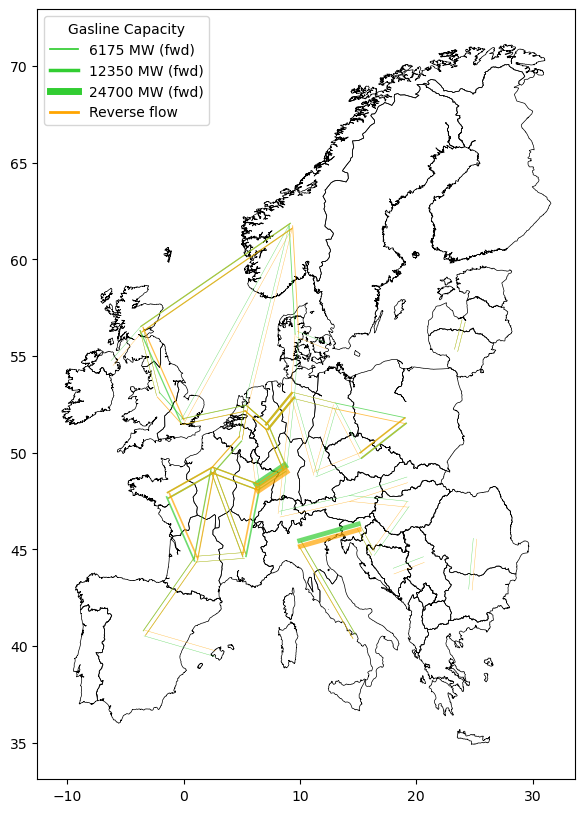

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

regions.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5)
# Get all gas pipeline links and their capacities
gas_links = n.links.loc[n.links.carrier == 'gas pipeline']
capacities = gas_links['p_nom'].fillna(0)
max_capacity = capacities.max() if not capacities.empty else 1

# Define color and width scaling
lime_color = '#32CD32'  # dark lime
max_width = 5

# For legend: pick 3 representative widths
legend_caps = [max_capacity * f for f in [0.25, 0.5, 1.0]]
legend_lines = []

import numpy as np

# Define colors for forward and reverse
forward_color = lime_color  # ensure forward is dark lime green
reverse_color = 'orange'
# Offset in data units (adjust as needed)
offset = 0.15

for idx, row in gas_links.iterrows():
    bus0 = row['bus0']
    bus1 = row['bus1']
    # Get coordinates of bus0 and bus1
    x0, y0 = n.buses.loc[bus0, ['x', 'y']]
    x1, y1 = n.buses.loc[bus1, ['x', 'y']]
    # Scale linewidth by capacity
    cap = row['p_nom'] if not pd.isnull(row['p_nom']) else 0
    width = (cap / max_capacity) * max_width if max_capacity > 0 else 1

    # Compute direction vector
    dx = x1 - x0
    dy = y1 - y0
    length = np.hypot(dx, dy)
    if length == 0:
        perp = np.array([0, 0])
    else:
        # Perpendicular unit vector (to the right of the direction)
        perp = np.array([-dy, dx]) / length

    # Determine if reversed
    shift = perp * offset
    if 'reversed' in idx:
        # Shift to the right of the direction
        color = reverse_color
        zorder = 4
    else:
        # Shift to the left of the direction
        color = forward_color  # ensure forward is dark lime green
        zorder = 3

    # Apply shift
    x0s, y0s = x0 + shift[0], y0 + shift[1]
    x1s, y1s = x1 + shift[0], y1 + shift[1]

    # Plot the line
    ax.plot([x0s, x1s], [y0s, y1s], color=color, linewidth=width, alpha=0.7, zorder=zorder)

    # Add black dot at origin (bus0) and white dot at destination (bus1)
    # ax.scatter(x0s, y0s, color='black', edgecolor='black', s=20, zorder=zorder+1)
    # ax.scatter(x1s, y1s, color='white', edgecolor='black', s=20, zorder=zorder+1)

# Add legend for line widths (forward, lime)
import matplotlib.lines as mlines
for cap in legend_caps:
    width = (cap / max_capacity) * max_width if max_capacity > 0 else 1
    line = mlines.Line2D([], [], color=forward_color, linewidth=width, label=f"{cap:.0f} MW (fwd)")
    legend_lines.append(line)
# Add a single orange line for reverse
legend_lines.append(mlines.Line2D([], [], color=reverse_color, linewidth=2, label="Reverse flow"))

ax.legend(handles=legend_lines, title="Gasline Capacity", loc='upper left')

plt.show()

In [14]:
n.generators.carrier.unique()

array(['nuclear', 'onwind', 'offwind-ac', 'offwind-dc', 'offwind-float',
       'solar', 'solar-hsat', 'ror', 'lignite', 'coal', 'oil primary',
       'gas', 'urban central heat vent', 'urban central solar thermal',
       'biogas', 'solid biomass', 'unsustainable biogas',
       'unsustainable solid biomass', 'unsustainable bioliquids',
       'solar rooftop', 'rural heat vent', 'rural solar thermal',
       'urban decentral heat vent', 'urban decentral solar thermal'],
      dtype=object)

In [16]:
path = Path.cwd().parent / 'resources'

In [17]:
gasinputs = gpd.read_file(path / 'gas_input_locations_s_50_simplified.csv').set_index('bus').replace('', 0).astype(float)
gasinputs.head()

,lng,pipeline,production,storage
bus,,,,
AT0 0,0.0000,0.000000,1785.956709,87281.743866
BE0 0,20780.2224,18782.828546,0.000000,545.280000
BG0 0,0.0000,17204.763033,0.000000,5680.000000
CZ0 0,0.0000,0.000000,0.000000,36712.942521
DE0 0,38509.3804,0.000000,12964.747171,122271.853683


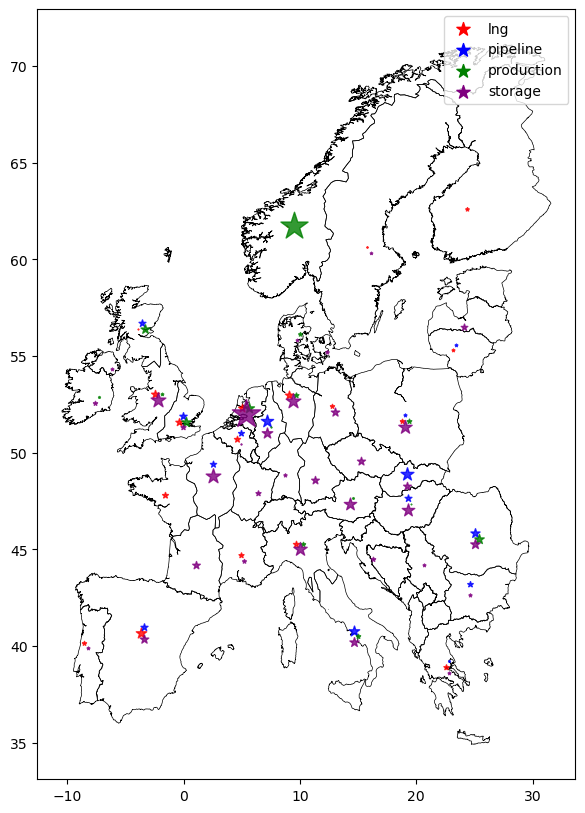

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))

regions.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5)

colours = {col: color for col, color in zip(gasinputs.columns, ['red', 'blue', 'green', 'purple'])}

for bus, row in gasinputs.iterrows():
    x, y = n.buses.loc[bus, ['x', 'y']
    ]

    # Offset positions for each entry to avoid overlap
    offsets = {
        'pipeline': (0, 0.3),    # up
        'production': (0.3, 0),  # right
        'storage': (0, -0.3),    # down
        'lng': (-0.3, 0),        # left
    }
    for entry in row.index:
        if row[entry] == 0:
            continue

        dx, dy = offsets.get(entry, (0, 0))
        ax.scatter(x + dx, y + dy, color=colours[entry], s=row[entry]/1000, marker='*', alpha=0.8)


for name, colour in colours.items():
    ax.scatter([], [], color=colour, s=100, marker='*', label=name)

ax.legend()

plt.show()

In [19]:
n.stores.loc[n.stores.carrier == 'gas'].sort_values(by='e_nom', ascending=False).head().T

Store,AL0 0 gas Store,LV0 0 gas Store,GB3 0 gas Store,GR0 0 gas Store,HR0 0 gas Store
bus,AL0 0 gas,LV0 0 gas,GB3 0 gas,GR0 0 gas,HR0 0 gas
type,,,,,
carrier,gas,gas,gas,gas,gas
e_nom,0.0,0.0,0.0,0.0,0.0
e_nom_mod,0.0,0.0,0.0,0.0,0.0
e_nom_extendable,True,True,True,True,True
e_nom_min,0.0,24424000.0,4696071.260504,4696071.260504,10035271.260504
e_nom_max,inf,inf,inf,inf,inf
e_min_pu,0.0,0.0,0.0,0.0,0.0
e_max_pu,1.0,1.0,1.0,1.0,1.0


In [20]:
n.loads.loc[n.loads.bus.str.contains('gas')].head()

,bus,carrier,type,p_set,q_set,sign,active
Load,,,,,,,
AL0 0 gas for industry,AL0 0 gas for industry,gas for industry,,79.908676,0.0,-1.0,True
AT0 0 gas for industry,AT0 0 gas for industry,gas for industry,,4099.315068,0.0,-1.0,True
BA0 0 gas for industry,BA0 0 gas for industry,gas for industry,,456.621005,0.0,-1.0,True
BE0 0 gas for industry,BE0 0 gas for industry,gas for industry,,6372.146119,0.0,-1.0,True
BG0 0 gas for industry,BG0 0 gas for industry,gas for industry,,1197.488584,0.0,-1.0,True


In [22]:
n.links.loc[n.links.bus0.str.contains('gas')].carrier.unique()

array(['OCGT', 'CCGT', 'gas pipeline', 'gas pipeline new', 'SMR CC',
       'SMR', 'urban central gas boiler', 'urban central gas CHP',
       'urban central gas CHP CC', 'biogas to gas', 'gas for industry',
       'gas for industry CC', 'rural gas boiler',
       'urban decentral gas boiler'], dtype=object)

In [24]:
n.links.loc[n.links.carrier == 'gas for industry'].head()

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,reversed,tags,length_original,geometry,underwater_fraction,project_status,location,under_construction,underground,energy to power ratio
Link,,,,,,,,,,,,,,,,,,,,,
AL0 0 gas for industry,AL0 0 gas,AL0 0 gas for industry,,gas for industry,1.0,True,0,inf,0.0,0.0,...,False,,0.0,,NaN,,,NaN,NaN,NaN
AT0 0 gas for industry,AT0 0 gas,AT0 0 gas for industry,,gas for industry,1.0,True,0,inf,0.0,0.0,...,False,,0.0,,NaN,,,NaN,NaN,NaN
BA0 0 gas for industry,BA0 0 gas,BA0 0 gas for industry,,gas for industry,1.0,True,0,inf,0.0,0.0,...,False,,0.0,,NaN,,,NaN,NaN,NaN
BE0 0 gas for industry,BE0 0 gas,BE0 0 gas for industry,,gas for industry,1.0,True,0,inf,0.0,0.0,...,False,,0.0,,NaN,,,NaN,NaN,NaN
BG0 0 gas for industry,BG0 0 gas,BG0 0 gas for industry,,gas for industry,1.0,True,0,inf,0.0,0.0,...,False,,0.0,,NaN,,,NaN,NaN,NaN
